# Transfer Experiments Analysis

Analyze cross-architecture transfer of Infusion perturbations.

## 2×2 Transfer Matrix

|                    | Eval on ResNet | Eval on CNN |
|--------------------|----------------|-------------|
| **Infused by ResNet** | ResNet→ResNet  | ResNet→CNN  |
| **Infused by CNN**    | CNN→ResNet     | CNN→CNN     |

Key metrics:
- **Forward Transfer Rate**: ResNet→CNN / ResNet→ResNet
- **Reverse Transfer Rate**: CNN→ResNet / CNN→CNN

In [1]:
import json
import os
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [ ]:
# Configuration
RESULTS_DIR = Path('/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/cifar/results/transfer/')
LOG_PATH = RESULTS_DIR / 'transfer_log.jsonl'

In [ ]:
def load_transfer_results(latest_run_only: bool = True) -> pd.DataFrame:
    """Load transfer experiment results from JSONL.
    
    Args:
        latest_run_only: If True, only load experiments from the most recent run
                        (using run_id field)
    """
    if not LOG_PATH.exists():
        print(f"No results found at {LOG_PATH}")
        return pd.DataFrame()
    
    records = []
    with open(LOG_PATH, 'r') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    
    if not records:
        return pd.DataFrame()
    
    df = pd.DataFrame(records)
    
    if latest_run_only and 'run_id' in df.columns:
        # Filter out NaN/empty run_ids (from old entries without run_id)
        valid_run_ids = df['run_id'].dropna()
        valid_run_ids = valid_run_ids[valid_run_ids != '']
        
        if len(valid_run_ids) > 0:
            # Filter to the latest run_id (lexicographically largest = most recent)
            latest_run = valid_run_ids.max()
            df = df[df['run_id'] == latest_run].copy()
            print(f"Loaded {len(df)} samples (filtered to run_id: {latest_run})")
        elif 'timestamp' in df.columns:
            # Fall through to timestamp-based detection
            pass
    
    if latest_run_only and 'run_id' not in df.columns or (latest_run_only and 'run_id' in df.columns and len(df['run_id'].dropna()) == 0):
        if 'timestamp' in df.columns:
            # Fallback: use timestamp-based detection for old logs without run_id
            df['timestamp_parsed'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp_parsed')
            
            # Find run boundaries (gaps > 1 hour indicate separate runs)
            time_diffs = df['timestamp_parsed'].diff()
            run_boundaries = time_diffs > pd.Timedelta(hours=1)
            df['_run_id'] = run_boundaries.cumsum()
            
            # Keep only the latest run
            latest_run = df['_run_id'].max()
            df = df[df['_run_id'] == latest_run].copy()
            df = df.drop(columns=['timestamp_parsed', '_run_id'])
            
            print(f"Loaded {len(df)} samples (filtered by timestamp)")
        else:
            print(f"Loaded {len(df)} transfer experiment results")
    elif not latest_run_only:
        print(f"Loaded {len(df)} transfer experiment results (all runs)")
    
    return df

In [4]:
# Load data from the LATEST RUN only
# Set latest_run_only=False to load all historical data
df = load_transfer_results(latest_run_only=True)

if df.empty:
    print("\nNo experiment data found. Run transfer experiments first.")

Loaded 100 samples (filtered to run_id: 20260118_173502)


## Summary Statistics

In [5]:
if not df.empty:
    # Summary for each condition
    conditions = [
        ('delta_prob_resnet_resnet', 'ResNet→ResNet'),
        ('delta_prob_resnet_cnn', 'ResNet→CNN'),
        ('delta_prob_cnn_resnet', 'CNN→ResNet'),
        ('delta_prob_cnn_cnn', 'CNN→CNN'),
    ]
    
    print("Summary Statistics for each condition:\n")
    print(f"{'Condition':<20} {'N':>5} {'Mean':>10} {'Std':>10} {'Success %':>10}")
    print("-" * 60)
    
    for col, name in conditions:
        if col in df.columns:
            data = df[col].dropna()
            n = len(data)
            mean = data.mean()
            std = data.std()
            success = (data > 0).mean() * 100
            print(f"{name:<20} {n:>5} {mean:>10.4f} {std:>10.4f} {success:>9.1f}%")

Summary Statistics for each condition:

Condition                N       Mean        Std  Success %
------------------------------------------------------------
ResNet→ResNet          100     0.2059     0.2970     100.0%
ResNet→CNN             100     0.0102     0.0340      80.0%
CNN→ResNet             100     0.0236     0.0682      97.0%
CNN→CNN                100     0.1401     0.2516     100.0%


## 2×2 Transfer Heatmap

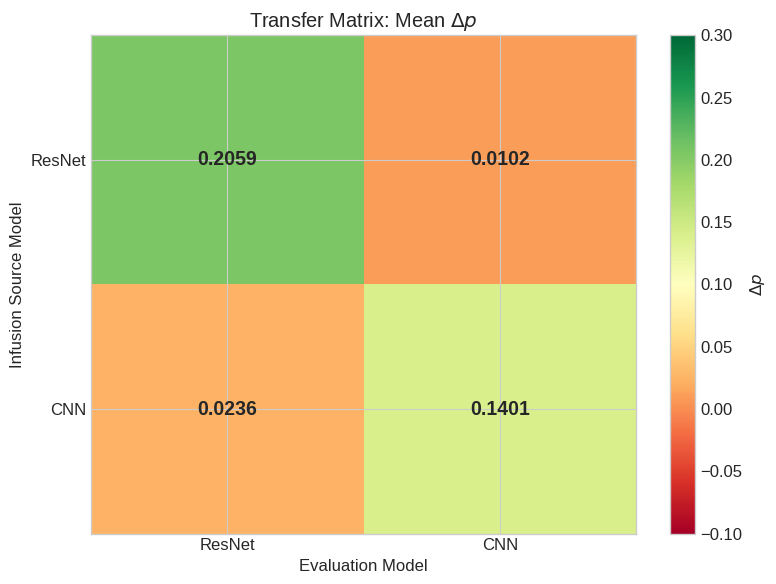

In [6]:
def plot_transfer_heatmap(df: pd.DataFrame):
    """Create 2×2 heatmap of mean delta_prob."""
    if df.empty:
        return
    
    # Create 2×2 matrix
    matrix = np.array([
        [df['delta_prob_resnet_resnet'].mean(), df['delta_prob_resnet_cnn'].mean()],
        [df['delta_prob_cnn_resnet'].mean(), df['delta_prob_cnn_cnn'].mean()]
    ])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.3)
    
    # Labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['ResNet', 'CNN'])
    ax.set_yticklabels(['ResNet', 'CNN'])
    ax.set_xlabel('Evaluation Model')
    ax.set_ylabel('Infusion Source Model')
    ax.set_title('Transfer Matrix: Mean $\\Delta p$')
    
    # Add values
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{matrix[i, j]:.4f}',
                          ha='center', va='center', fontsize=14, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('$\\Delta p$')
    
    plt.tight_layout()
    plt.savefig('figures/transfer_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_transfer_heatmap(df)

## Transfer Rates

In [7]:
def analyze_transfer_rates(df: pd.DataFrame):
    """Analyze transfer rates."""
    if df.empty:
        return
    
    # Forward transfer: ResNet→CNN / ResNet→ResNet
    forward = df['transfer_rate_forward'].dropna()
    # Reverse transfer: CNN→ResNet / CNN→CNN  
    reverse = df['transfer_rate_reverse'].dropna()
    
    print("\nTransfer Rate Analysis:\n")
    
    print("Forward Transfer (ResNet→CNN / ResNet→ResNet):")
    print(f"  N: {len(forward)}")
    print(f"  Mean: {forward.mean():.3f}")
    print(f"  Median: {forward.median():.3f}")
    print(f"  Std: {forward.std():.3f}")
    print(f"  % > 0.5: {(forward > 0.5).mean() * 100:.1f}%")
    print(f"  % > 1.0: {(forward > 1.0).mean() * 100:.1f}%")
    
    print("\nReverse Transfer (CNN→ResNet / CNN→CNN):")
    print(f"  N: {len(reverse)}")
    print(f"  Mean: {reverse.mean():.3f}")
    print(f"  Median: {reverse.median():.3f}")
    print(f"  Std: {reverse.std():.3f}")
    print(f"  % > 0.5: {(reverse > 0.5).mean() * 100:.1f}%")
    print(f"  % > 1.0: {(reverse > 1.0).mean() * 100:.1f}%")


if not df.empty:
    analyze_transfer_rates(df)


Transfer Rate Analysis:

Forward Transfer (ResNet→CNN / ResNet→ResNet):
  N: 100
  Mean: 0.084
  Median: 0.000
  Std: 0.322
  % > 0.5: 4.0%
  % > 1.0: 4.0%

Reverse Transfer (CNN→ResNet / CNN→CNN):
  N: 96
  Mean: 1.771
  Median: 0.124
  Std: 5.911
  % > 0.5: 27.1%
  % > 1.0: 19.8%


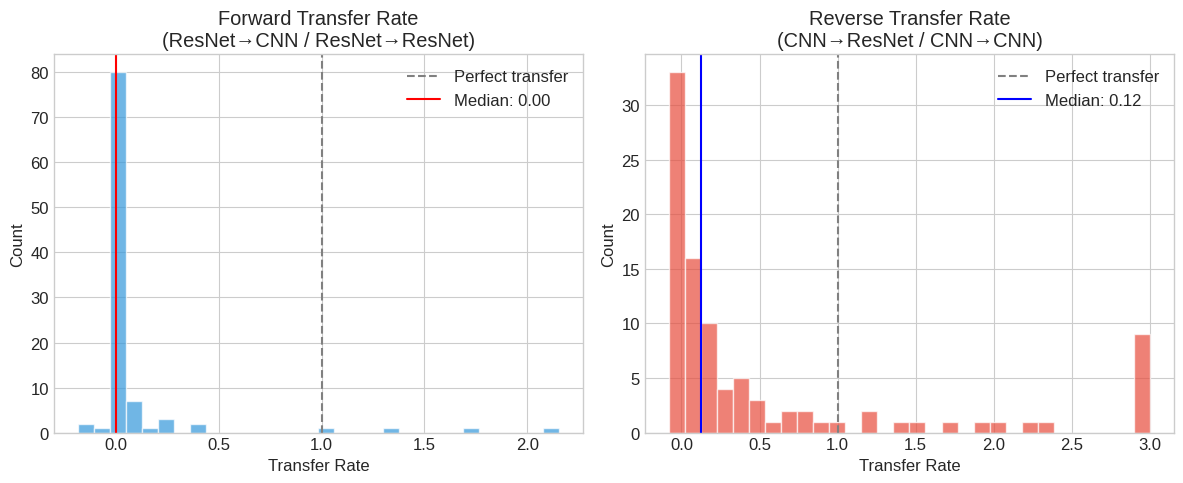

In [8]:
def plot_transfer_rates(df: pd.DataFrame):
    """Plot transfer rate distributions."""
    if df.empty:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Forward transfer
    ax1 = axes[0]
    forward = df['transfer_rate_forward'].dropna()
    forward_clipped = forward.clip(-2, 3)  # Clip outliers for visualization
    ax1.hist(forward_clipped, bins=30, alpha=0.7, color='#3498db', edgecolor='white')
    ax1.axvline(x=1.0, color='gray', linestyle='--', label='Perfect transfer')
    ax1.axvline(x=forward.median(), color='red', linestyle='-', label=f'Median: {forward.median():.2f}')
    ax1.set_xlabel('Transfer Rate')
    ax1.set_ylabel('Count')
    ax1.set_title('Forward Transfer Rate\n(ResNet→CNN / ResNet→ResNet)')
    ax1.legend()
    
    # Reverse transfer
    ax2 = axes[1]
    reverse = df['transfer_rate_reverse'].dropna()
    reverse_clipped = reverse.clip(-2, 3)
    ax2.hist(reverse_clipped, bins=30, alpha=0.7, color='#e74c3c', edgecolor='white')
    ax2.axvline(x=1.0, color='gray', linestyle='--', label='Perfect transfer')
    ax2.axvline(x=reverse.median(), color='blue', linestyle='-', label=f'Median: {reverse.median():.2f}')
    ax2.set_xlabel('Transfer Rate')
    ax2.set_ylabel('Count')
    ax2.set_title('Reverse Transfer Rate\n(CNN→ResNet / CNN→CNN)')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'transfer_rates.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_transfer_rates(df)

## Same vs Cross-Architecture Comparison

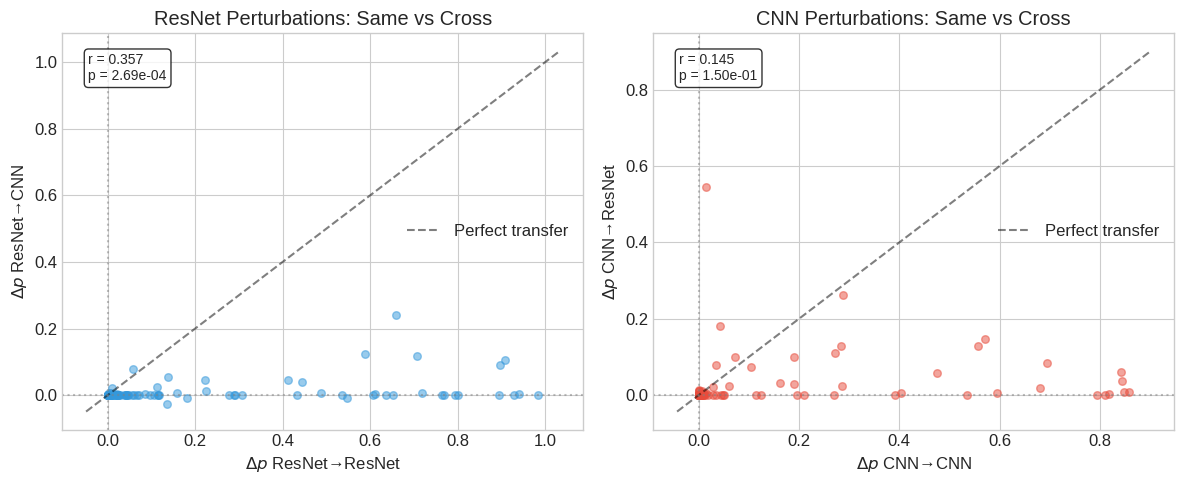

In [9]:
def plot_same_vs_cross(df: pd.DataFrame):
    """Compare same-architecture vs cross-architecture effects."""
    if df.empty:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ResNet as source
    ax1 = axes[0]
    ax1.scatter(df['delta_prob_resnet_resnet'], df['delta_prob_resnet_cnn'], 
               alpha=0.5, s=30, color='#3498db')
    
    # Add diagonal (perfect transfer)
    lims = [min(ax1.get_xlim()[0], ax1.get_ylim()[0]), 
            max(ax1.get_xlim()[1], ax1.get_ylim()[1])]
    ax1.plot(lims, lims, 'k--', alpha=0.5, label='Perfect transfer')
    ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    
    ax1.set_xlabel('$\\Delta p$ ResNet→ResNet')
    ax1.set_ylabel('$\\Delta p$ ResNet→CNN')
    ax1.set_title('ResNet Perturbations: Same vs Cross')
    ax1.legend()
    
    # Correlation
    r, p = stats.pearsonr(df['delta_prob_resnet_resnet'].dropna(), 
                          df['delta_prob_resnet_cnn'].dropna())
    ax1.annotate(f'r = {r:.3f}\np = {p:.2e}', xy=(0.05, 0.95), 
                xycoords='axes fraction', ha='left', va='top',
                fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # CNN as source
    ax2 = axes[1]
    ax2.scatter(df['delta_prob_cnn_cnn'], df['delta_prob_cnn_resnet'],
               alpha=0.5, s=30, color='#e74c3c')
    
    lims = [min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
            max(ax2.get_xlim()[1], ax2.get_ylim()[1])]
    ax2.plot(lims, lims, 'k--', alpha=0.5, label='Perfect transfer')
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    
    ax2.set_xlabel('$\\Delta p$ CNN→CNN')
    ax2.set_ylabel('$\\Delta p$ CNN→ResNet')
    ax2.set_title('CNN Perturbations: Same vs Cross')
    ax2.legend()
    
    # Correlation
    r, p = stats.pearsonr(df['delta_prob_cnn_cnn'].dropna(),
                          df['delta_prob_cnn_resnet'].dropna())
    ax2.annotate(f'r = {r:.3f}\np = {p:.2e}', xy=(0.05, 0.95),
                xycoords='axes fraction', ha='left', va='top',
                fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'transfer_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_same_vs_cross(df)

## Box Plot Comparison

/local/user/1483801484/ipykernel_138544/992079836.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


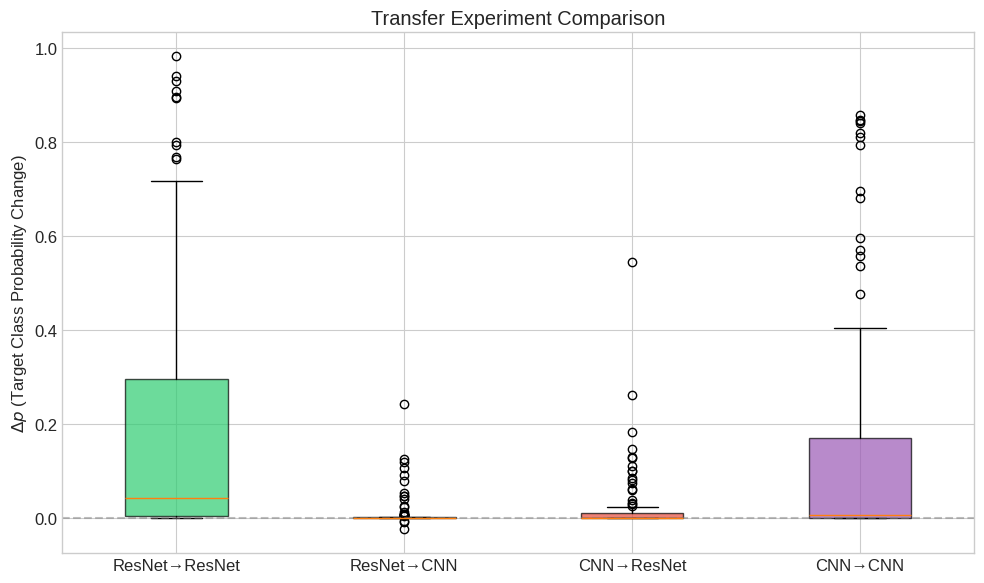

In [10]:
def plot_boxplot_comparison(df: pd.DataFrame):
    """Box plot comparing all 4 conditions."""
    if df.empty:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data = [
        df['delta_prob_resnet_resnet'].dropna(),
        df['delta_prob_resnet_cnn'].dropna(),
        df['delta_prob_cnn_resnet'].dropna(),
        df['delta_prob_cnn_cnn'].dropna(),
    ]
    labels = ['ResNet→ResNet', 'ResNet→CNN', 'CNN→ResNet', 'CNN→CNN']
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('$\\Delta p$ (Target Class Probability Change)')
    ax.set_title('Transfer Experiment Comparison')

    
    plt.tight_layout()
    plt.savefig('figures/transfer_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_boxplot_comparison(df)

## Progress Tracking

In [11]:
def show_progress(df: pd.DataFrame, expected_n: int = 100):
    """Show experiment progress."""
    n = len(df) if not df.empty else 0
    pct = n / expected_n * 100
    bar = '=' * int(pct / 5) + ' ' * (20 - int(pct / 5))
    
    print(f"\nTransfer Experiment Progress:\n")
    print(f"[{bar}] {n:>3}/{expected_n} ({pct:.0f}%)")


show_progress(df)


Transfer Experiment Progress:

[====================] 100/100 (100%)
